# Storyline Analysis - Zappa & Shepherd (2017)

This notebook reproduces the Zappa & Shepherd (2017) storyline regression methodology applied to the Mediterranean region using CMIP6
models under SSP5-8.5.

Two processing pathways are available:

| Option | Preprocessor | When to use |
|--------|-------------|-------------|
| **A** | ESMValTool | Standard DJF or predefined seasons; reproducible with recipe |
| **B** | Local CMIP files | Custom seasons (e.g. NDJFM); no ESMValTool required |

Both options produce the same downstream outputs (`target_pr.nc`,
`scaled_standardized_drivers.csv`) and use the same regression and
storyline evaluation code.

---
**Reference:** Zappa & Shepherd (2017)

## Option A: ESMValTool pipeline

**Prerequisites:** An ESMValTool recipe run must be completed before
running this section.

**Steps:**
1. Load ESMValTool config and user config
2. Process target variable (`target_pr.nc`)
3. Compute driver indices (`scaled_standardized_drivers.csv`)

### Step 1A - Compute target

In [2]:
from storypy.preprocess import ESMValProcessor, parse_config

In [ ]:
"""
The config dictionary below contains user-defined settings for the analysis using ESMValTool.
"""
main_config = dict(
        work_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work',
        plot_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/plots',
        var_name=['pr'],
        exp_name='ssp585',
        freq='mon',
        grid='g025',
        variant_selection = 'mean',
        region_method='box',
        period1 = [1960, 1990],   # reference
        period2 = [2070, 2100],   # future
        region_id=18,
        season=(11, 12, 1, 2, 3),
        region_extents=[(30, 45, -10, 40), (45, 55, 5, 20)],
        # region_extents=[(-90, 90, -180, 180)],
        box=([-25, 45, 30, 65]),
        titles=["Region A", "Region B"]
    )

# Load the configuration file
esmval_config= parse_config('/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/run/storyline_analysis/multiple_regression/settings.yml')

In [4]:
processor_target_A = ESMValProcessor(esmval_config, main_config)

In [ ]:
processor_target_A.process_var()

### Step 2A - Compute driver indices

Driver indices (eum, naw, gw) are computed from the ESMValTool
preprocessed files and written to `remote_drivers/` as three CSV files:

- `drivers.csv` - raw anomalies (K or m/s)
- `scaled_drivers.csv` - anomaly / GW scalar
- `scaled_standardized_drivers.csv` - z-scored, used in regression

**`season_months`:** Set to `None` if `general_preproc` was applied in
the recipe (i.e. ESMValTool did the seasonal averaging). Set to a list of
integers (e.g. `[12,1,2]` for DJF) if `general_preproc` is not applied and raw monthly data is delivered.

In [ ]:
from storypy.preprocess import parse_config
from storypy.compute import driver_indices

esmval_config= parse_config('/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/run/storyline_analysis/multiple_regression/settings.yml')
esmval_config['variant_selection'] = 'mean'
# esmval_config['season_months']     = None # Optional - if season selection and averaging is done in the ESMValTool recipe, then this should be set to None.
esmval_config['season_months'] = [11, 12, 1, 2, 3]
esmval_config['ref_period']    = ("1960", "1990")
esmval_config['future_period'] = ("2070", "2100")

df_raw, df_scaled, df_stand = driver_indices(esmval_config)

Saved drivers to /climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work/storyline_analysis/multiple_regresion/remote_drivers/drivers.nc (variant_selection='mean', season_months=[11, 12, 1, 2, 3])
Saved driver indices (variant_selection='mean', season_months=[11, 12, 1, 2, 3])


---

## Option B: Local CMIP file pipeline

**Prerequisites:** CMIP6 NetCDF files must be available locally in the
directory structure `{data_dir}/{variable}/{freq}/{grid}/`.

**Advantages over Option A:**
- No ESMValTool installation required
- Custom seasons not supported by ESMValTool (e.g. NDJFM `[11,12,1,2,3]`)
- Flexible reference and future periods

**Steps:**
1. Process target variable → `target_pr.nc`
2. Process each driver variable separately → `remote_driver_{name}.nc`
3. Compute driver indices → same CSV outputs as Option A

### Step 1B - Compute target from locally stored CMIP data

In [2]:
from storypy.preprocess import ModelDataPreprocessor

In [3]:
"""
The config dictionary below contains user-defined settings for the analysis using Logic2 [Model Data].
"""
main_config = dict(
        data_dir='/climca/data/cmip6-ng',
        work_dir='/climca/people/storylinetool/test_user/storypy_usage/work/zs_17',
        plot_dir='/climca/people/storylinetool/test_user/storypy_usage/plots/zs_17',
        var_name=['pr'],
        exp_name='ssp585',
        freq='mon',
        grid='g025',
        region_method='box',
        period1 = [1960, 1990],
        period2 = [2070, 2100],
        region_id=18,
        season=(11, 12, 1, 2, 3),  # Now provided as a tuple of months
        region_extents=[(30, 45, -10, 40), (45, 55, 5, 20)],
        # box=(-13.75, 43.75, 26.25, 58.75),
        titles=["Region A", "Region B"]
    )


In [4]:
processor_target_B= ModelDataPreprocessor(main_config)

Common model+members across all variables: {'UKESM1-0-LL_r12i1p1f2', 'IPSL-CM6A-LR_r15i1p1f1', 'MPI-ESM1-2-LR_r36i1p1f1', 'ACCESS-ESM1-5_r16i1p1f1', 'CNRM-CM6-1_r9i1p1f2', 'CAS-ESM2-0_r3i1p1f1', 'CNRM-ESM2-1_r9i1p1f2', 'EC-Earth3_r101i1p1f1', 'CMCC-CM2-HR4_r1i1p1f1', 'CanESM5-CanOE_r1i1p2f1', 'EC-Earth3_r149i1p1f1', 'AWI-CM-1-1-MR_r3i1p1f1', 'HadGEM3-GC31-LL_r55i1p1f3', 'EC-Earth3_r145i1p1f1', 'EC-Earth3_r140i1p1f1', 'HadGEM3-GC31-LL_r53i1p1f3', 'MPI-ESM1-2-LR_r7i1p1f1', 'E3SM-1-0_r7i2p2f1', 'IPSL-CM6A-LR-INCA_r1i1p1f1', 'CMCC-CM2-SR5_r9i1p2f1', 'E3SM-2-0-NARRM_r2i1p1f1', 'KACE-1-0-G_r1i1p1f1', 'AWI-ESM-1-REcoM_r1i1p1f1', 'MIROC6_r41i1p1f1', 'EC-Earth3_r114i1p1f1', 'UKESM1-0-LL_r7i1p1f3', 'CNRM-CM6-1_r22i1p1f2', 'NorCPM1_r13i1p1f1', 'GISS-E2-1-H_r2i1p1f1', 'GISS-E2-1-G_r10i1p1f2', 'CanESM5-1_r27i1p1f1', 'CNRM-ESM2-1_r7i1p1f2', 'EC-Earth3_r128i1p1f1', 'NorCPM1_r16i1p1f1', 'EC-Earth3-Veg_r2i1p1f1', 'IPSL-CM6A-LR_r31i1p1f1', 'CanESM5_r5i1p2f1', 'ACCESS-ESM1-5_r39i1p1f1', 'MIROC6_r27i1p1f1

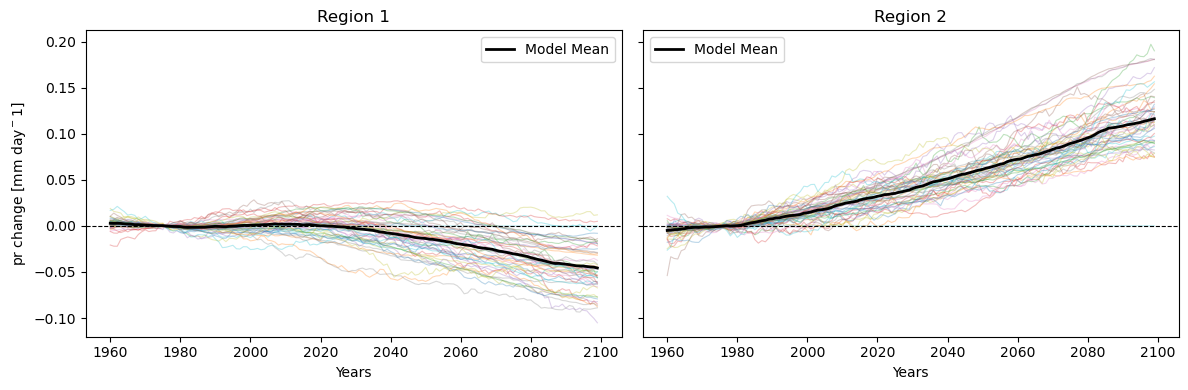

In [5]:
processor_target_B.process_var()

### Step 2B - Compute driver variables

Each driver is processed separately with its own spatial region and period. The GW driver (`short_name='gw'`) must always be included - it is used to normalise all other drivers.

The `process_driver()` call writes one NetCDF file per driver to
`work_dir`:
- `remote_driver_ta.nc` - Tropical Warming / Tropical Amplification
- `remote_driver_pa.nc` - Polar Warming / Polar Amplification
- `remote_driver_spv.nc` - Stratospheric Polar Warming
- `remote_driver_gw.nc` - Global warming scalar (required by `compute_drivers`)

In [ ]:
driver_config = dict(
    var_name   = ['ua'],
    short_name = ['spv'],
    period1    = [1960, 1999],   # reference
    period2    = [2060, 2099],   # future
    season     = [7, 8, 9],      # JAS 
    box        = {               
        'lat_min': -30,
        'lat_max':  50,
        'lon_min':   0,
        'lon_max':  40
    },
    work_dir   = '/climca/people/storylinetool/test_user/storypy_usage/work/zs_17'
)


In [ ]:
from storypy.preprocess import ModelDataPreprocessor

# Driver indices
proc_driver = ModelDataPreprocessor(main_config, driver_config)
proc_driver.process_driver()
# → writes remote_driver.nc


In [ ]:
from storypy.compute import compute_drivers
"""
The compute_drivers function will use the computed driver variables to calculate the raw, scaled, and standardized driver indices for each model.
The results will be returned as three separate DataFrames: df_raw, df_scaled, and df_stand.
Each DataFrame will contain the driver indices for all models, which can then be used for regression analysis or saved to CSV files for further analysis.

Also, the function can directly read drivers.nc (from option A) file from a specified directory, which is expected to contain the necessary driver variables.
The function will look for the drivers.nc file in the provided work_dir and its subdirectory remote_drivers. If the file is found, it will be used to compute the driver indices
This allows for flexibility in how the driver data is organized and accessed for analysis.
"""

driver_config = dict(
        var_name=['tas', 'ua850'],            # <- actual variable names in NetCDF
        short_name=['ta', 'spv'],           # <- names for regression/CSV outputs
        work_dir='/climca/people/storylinetool/test_user/storypy_usage/work/zs_17'
    )
df_raw, df_scaled, df_stand = compute_drivers(driver_config)

---

## Step 3 - Significance testing for spatial maps

Two significance tests are available:

### Beta significance (model agreement)
Flags gridpoints where ≥N% of models agree on the sign of change.
Works directly from `target_pr.nc` - no additional ESMValTool run needed.

### Gamma significance (signal-to-noise)
Flags gridpoints where the forced signal exceeds internal variability.
Requires a separate piControl ESMValTool recipe run delivering raw
monthly variable (e.g. PR, with no seasonal averaging, no anomaly extraction).

The output NetCDF files are passed to `plot_function` as stippling masks.

In [ ]:
# Beta - no piControl needed. It directly uses the computed target variable data to assess the significance of the trends across models.
# The beta_significance method will analyze the agreement among the models for the specified target variable and
# determine which grid points show significant positive or negative trends based on the agreement threshold (0.9 (90%) in this case).
# The output will be two arrays: pos for significant positive trends and neg for significant negative trends, which can be used for further analysis or visualization.

from storypy.compute import StipplingComputer

work_dir = '/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work'

sc = StipplingComputer(work_dir=work_dir, target_variable='pr')
pos, neg = sc.beta_significance(agreement_threshold=0.9)


## Gamma Significance Test (γ criterion)

The γ criterion follows [Zappa et al. (2021)](https://doi.org/10.1002/joc.7041)
and quantifies whether the forced precipitation signal is large relative to internal
climate variability estimated from piControl simulations.

### How it works

At each gridpoint, γ is defined as:

$$\gamma = \frac{|\Delta P_{\text{forced}}|}{\sigma_{\text{piControl}}}$$

where $\Delta P_{\text{forced}}$ is the multi-model mean forced signal from `target_pr.nc`
and $\sigma_{\text{piControl}}$ is the standard deviation of non-overlapping 30-year
rolling means from the piControl simulation. A gridpoint is flagged (γ > 1) where the
forced signal exceeds the amplitude of internal variability.

### Running the gamma significance test

The γ test requires piControl data preprocessed via ESMValTool. It is run as a
**separate ESMValTool recipe** using the diagnostic script `file_name.py`:

**Recipe snippet (`file_name.yml`):**
```yaml
diagnostics:
  multiple_regression_indices:
    variables:
      pr:
        exp:
        - piControl
        mip: Amon
        preprocessor: PR
        project: CMIP6
        short_name: pr
        timerange: '*'
        additional_datasets: *dAmon
    scripts:
      significance:
        script: /path/to/file_name.py
        target_work_dir: /path/to/your/storypy/work_dir
```

**Diagnostic script (`file_name.py`):**
```python
from esmvaltool.diag_scripts.shared import run_diagnostic
from storypy.compute import StipplingComputer

def main(config):
    sc_gamma = StipplingComputer(
        work_dir          = config['target_work_dir'],
        target_variable   = 'pr',
        picontrol_config  = config,
        variable_group    = 'pr',
        season_months     = [11, 12, 1, 2, 3],  # NDJFM
        variant_selection = 'mean',
    )
    sc_gamma.gamma_significance(rolling_window=30)

if __name__ == '__main__':
    with run_diagnostic() as config:
        main(config)
```

The script is run via the ESMValTool CLI:
```bash
esmvaltool run file_name.yml
```

### Outputs

The diagnostic saves two NetCDF files to `{target_work_dir}/stippling/`:

| File | Description |
|---|---|
| `gamma_forced_CMIP6.nc` | Median γ ratio across models (signal / noise) |
| `summatory_denom_CMIP6.nc` | Sum of 1/σ² across models (denominator weight) |

### Parameters

| Parameter | Value | Description |
|---|---|---|
| `target_variable` | `'pr'` | Variable to analyse |
| `picontrol_config` | `config` | ESMValTool config dict passed automatically by `run_diagnostic` |
| `variable_group` | `'pr'` | Variable group name in the ESMValTool piControl recipe |
| `season_months` | `[11, 12, 1, 2, 3]` | Months selected before computing rolling statistics (NDJFM) |
| `variant_selection` | `'mean'` | How to handle multi-member piControl runs - averages γ across all available variants |
| `rolling_window` | `30` | Window length in years for the rolling mean used to estimate internal variability |

### Notes

> `target_work_dir` in the recipe script block must point to the **same** `work_dir`
> used in the main storypy pipeline, where `target_pr.nc` was written by
> `ESMValProcessor` or the local preprocessing option. This is how the diagnostic
> script locates the forced signal to compute γ.

> If piControl data is on a 0–360° longitude grid, `gamma_significance()` automatically
> re-wraps longitudes to −180/180° before the signal-to-noise computation to ensure
> correct spatial alignment with `target_pr.nc`.

In [ ]:
# Gamma — point at piControl ESMValTool settings. It uses the piControl data to compute the gamma significance of the trends in the target variable across models.
# The gamma_significance method will analyze the variability in the piControl data to determine which grid points show significant trends in the target variable based on a rolling window approach (30 years in this case).
# The output will be an array indicating the significance of the trends, which can be used for further analysis or visualization.
from storypy.preprocess import parse_config
from storypy.compute import StipplingComputer

work_dir = '/climca/people/ralawode/esmvaltool_output/.../work'
picontrol_cfg = parse_config('/path/to/picontrol_run/settings.yml')
sc_gamma = StipplingComputer(
    work_dir          = work_dir,
    target_variable   = 'pr',
    picontrol_config  = picontrol_cfg,
    variable_group    = 'pr_picontrol',
    season_months     = [11, 12, 1, 2, 3],  # NDJFM
    variant_selection = 'mean',
)
gamma, denom = sc_gamma.gamma_significance(rolling_window=30)

## Stippling Visualisation

This cell produces a map of projected precipitation change with significance stippling
following the approach of [Zappa et al. (2021)](https://doi.org/10.1002/joc.7041)
as implemented in [Mindlin et al. (2023)](https://doi.org/10.1175/JCLI-D-22-0486.1).

### Stippling criteria

Two independent significance criteria are visualised:

- **Filled dots (β criterion)** - Model agreement on sign of change. Shown where ≥ 90%
  of CMIP models agree on the direction of the projected change at a given gridpoint.
  Computed by `StipplingComputer.beta_significance()`.

- **Open circles (γ criterion)** - Large signal relative to internal variability. Shown
  where the forced signal exceeds the piControl internal variability at a given gridpoint
  (γ > 1). Computed by `StipplingComputer.gamma_significance()`.

- **Filled dot inside open circle** - Both criteria are satisfied: the projected change
  is large relative to internal variability *and* models robustly agree on its sign.

### Inputs

| Variable | Description |
|---|---|
| `target_mean` | Multi-model mean precipitation change (mm/day), averaged over the model ensemble |
| `pos_ds` | Binary mask where ≥ 90% of models project a positive change (`beta_significance`) |
| `neg_ds` | Binary mask where ≥ 90% of models project a negative change (`beta_significance`) |
| `gamma_as_pval` | Binary mask derived from γ ratio: 0 where γ > 1 (significant), 1 elsewhere |
| `region_extents` | List of `(lat_min, lat_max, lon_min, lon_max)` tuples for region boxes |

### Parameters

| Parameter | Default | Description |
|---|---|---|
| `sig_level` | `0.5` | Threshold applied to `gamma_as_pval` — values below this are flagged as γ > 1 |
| `sig` | `1` | Value indicating agreement in beta masks (sum of pos + neg masks equals this) |
| `projection` | `'robinson'` | Map projection: `'robinson'` for global, `'platecarree'` for regional |
| `map_extent` | `None` | `[lon_min, lon_max, lat_min, lat_max]` to zoom into a region; global if `None` |

### Notes

> The `gamma_as_pval` array is constructed from the raw γ ratio saved in
> `gamma_forced_CMIP6.nc` by converting it to a pseudo p-value:
> `gamma_as_pval = xr.where(gamma > 1.0, 0.0, 1.0)`.
> This ensures compatibility with the `p_values < sig_level` threshold in `plot_function`.

> piControl data must cover the full global domain. If piControl files are in a 0–360°
> longitude convention, `StipplingComputer.gamma_significance()` automatically
> re-wraps longitudes to −180/180° before computing the signal-to-noise ratio.

In [ ]:
from storypy.evaluate.plot import plot_function
import xarray as xr
import os

work_dir = ('/climca/people/ralawode/esmvaltool_output/'
            'za_sh_2017_20260423_084917/work')

# Target - multi-model mean
target = xr.open_dataset(os.path.join(work_dir, 'target_pr.nc'))
target_mean = target['pr'].mean(dim='model')

# Stippling masks from beta test
pos_ds = xr.open_dataset(
    os.path.join(work_dir, 'stippling',
                 'number_of_models_positive_trend_CMIP6.nc')
)
neg_ds = xr.open_dataset(
    os.path.join(work_dir, 'stippling',
                 'number_of_models_negative_trend_CMIP6.nc')
)

# Plot
fig = plot_function(
    target_change   = target_mean,
    p_values        = None,
    positives_model = pos_ds,
    negatives_model = neg_ds,
    region_extents  = [(30, 45, -10, 40)],
    sig             = 1,
    # projection      = 'robinson',
    map_extent      = [-30, 60, 15, 70],
)

In [ ]:
from storypy.evaluate.plot import plot_function
import xarray as xr
import os

work_dir = '/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work'

# Target
target      = xr.open_dataset(os.path.join(work_dir, 'target_pr.nc'))
target_mean = target['pr'].mean(dim='model')

# Gamma mask — fix lon convention to match target (-180 to 180)
gamma_ds = xr.open_dataset(os.path.join(work_dir, 'stippling',
                            'gamma_forced_CMIP6.nc'))
gamma    = gamma_ds['gamma']

gamma_as_pval = xr.where(gamma > 1.0, 0.0, 1.0)  # 0 = significant


fig = plot_function(
    target_change    = target_mean,
    p_values         = gamma_as_pval,
    positives_model  = None,
    negatives_model  = None,
    region_extents   = [(30, 45, -10, 40)],
    sig_level        = 0.5,
    sig              = 1,
    # projection      = 'robinson',
    map_extent      = [-30, 60, 15, 70]
)



In [ ]:
from storypy.evaluate.plot import plot_function
import xarray as xr
import os

work_dir = '/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work'

# Target
target      = xr.open_dataset(os.path.join(work_dir, 'target_pr.nc'))
target_mean = target['pr'].mean(dim='model')

# Beta masks
pos_ds = xr.open_dataset(os.path.join(work_dir, 'stippling',
                         'number_of_models_positive_trend_CMIP6.nc'))
neg_ds = xr.open_dataset(os.path.join(work_dir, 'stippling',
                         'number_of_models_negative_trend_CMIP6.nc'))

# Gamma mask — fix lon convention to match target (-180 to 180)
gamma_ds = xr.open_dataset(os.path.join(work_dir, 'stippling',
                            'gamma_forced_CMIP6.nc'))
gamma    = gamma_ds['gamma']

gamma_as_pval = xr.where(gamma > 1.0, 0.0, 1.0)  # 0 = significant

# # Full globe
# fig = plot_function(
#     target_change   = target_mean,
#     p_values        = gamma_as_pval,
#     positives_model = pos_ds,
#     negatives_model = neg_ds,
#     region_extents  = [(30, 45, -10, 40)],
#     sig_level       = 0.5,
#     sig             = 1,
#     projection      = 'robinson',
# )

# Zoomed in
fig = plot_function(
    target_change   = target_mean,
    p_values        = gamma_as_pval,
    positives_model = pos_ds,
    negatives_model = neg_ds,
    region_extents  = [(30, 45, -10, 40), (45, 55, 5, 20)],
    sig_level       = 0.5,
    sig             = 1,
    projection      = 'platecarree',
    map_extent      = [-30, 60, 15, 70],
)

---

## Step 4 - Regression analysis

Reads `target_pr.nc` and `scaled_standardized_drivers.csv` from
`work_dir` and fits an OLS multiple linear regression:

ΔPR/ΔGW = β₀·MEM + β₁·driver₁ + β₂·driver₂ + ...

where MEM is the multi-model ensemble mean pattern and each `βᵢ`
coefficient shows how much additional precipitation change is associated
with a 1-standard-deviation anomaly in that driver.

**Output:** `regression_output/pr/regression_coefficients.nc` containing
one spatial map per regressor (`MEM`, `naw`, `eum`, etc.).

In [1]:
from storypy.compute import compute_regression
"""
The compute_regression function will perform regression analysis using the computed driver indices and the target variable.
The function will read the target variable data from the specified work_dir, and use the driver indices from the compute_drivers function to fit a regression model.
It needs target.nc, and scaled_standardized_drivers.csv files in the specified work_dir to perform the regression analysis.
The [work_dir + target.nc] file should contain the target variable data, while the [work_dir + remote_drivers/scaled_standardized_drivers.csv] file should contain the computed driver indices.
"""

main_config = dict(
        work_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work',
        target_variable=['pr']
    )
outputs = compute_regression(main_config)

This is regressor_coefs: <xarray.Dataset> Size: 334kB
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB -178.8 -176.2 -173.8 -171.2 ... 173.8 176.2 178.8
Data variables:
    pr       (lat, lon) float64 83kB 0.02502 0.02515 0.02535 ... 0.1077 0.1069
    pw       (lat, lon) float64 83kB 0.004548 0.004521 ... 0.001363 0.00135
    spv      (lat, lon) float64 83kB -0.001382 -0.001254 ... 0.002932 0.002695
    ta       (lat, lon) float64 83kB 0.0007005 0.0007693 ... -0.02407 -0.02447
Regression completed for: pr


---

## Step 5 - Driver spread and storyline evaluation

### 5a - Driver spread boxplot
Shows the cross-model spread in each standardised driver index.

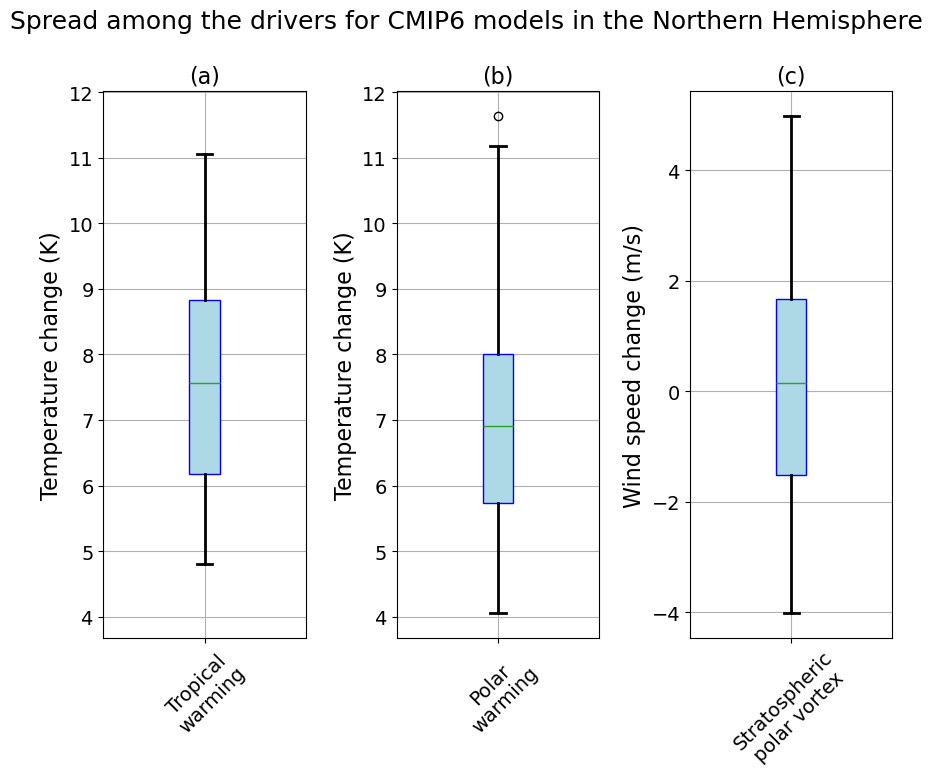

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.titlesize": 18
})

# Load dataset
main_config = dict(
        work_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work',
        plot_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/plots',
    )

# Directly read the drivers from the output file in the work_dir.
driver_path = os.path.join(main_config['work_dir'], "storyline_analysis/multiple_regression/remote_drivers/drivers.csv")
rds = pd.read_csv(driver_path, index_col=0)

# Choose/re-order the panel explicitly
driver_order = ["ta", "pw", "spv"]

# Keep only those that exist in the CSV (avoids KeyError)
driver_order = [d for d in driver_order if d in rds.columns]

# x labels
pretty_names = {
    "spv": "Stratospheric\npolar vortex",
    # "gw":  "Global\nwarming",
    "ta":  "Tropical\nwarming",
    "pw":  "Polar\nwarming",
}

# Per-panel y-labels
ylabels = {
    "spv": "Wind speed change (m/s)",
    # "gw":  "Temperature change (K)",
    "ta":  "Temperature change (K)",
    "pw":  "Temperature change (K)",
}

n = len(driver_order)

# -------------------------------------------------
shared_range = ["pw", "ta"]

# Compute shared y-limits for selected drivers
shared_min = rds[shared_range].min().min()
shared_max = rds[shared_range].max().max()

# Padding
pad = 0.05 * (shared_max - shared_min)
shared_ylim = (shared_min - pad, shared_max + pad)
# -------------------------------------------------

fig, axes = plt.subplots(
    1, n,
    figsize=(3.0 * n, 8),
    squeeze=False
)
axes = axes[0]


for i, (ax, col) in enumerate(zip(axes, driver_order)):
    rds[[col]].boxplot(
        ax=ax,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='blue'),
        whiskerprops=dict(color='black', linewidth=2),
        capprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', color='black', markersize=6)
    )

    ax.set_title(f"({chr(ord('a') + i)})")
    ax.set_xticklabels([pretty_names.get(col, col)], rotation=45, ha='center')
    ax.set_ylabel(ylabels.get(col, ""))

    # -------------------------------------------------
    if col in shared_range:
        ax.set_ylim(shared_ylim)
    # -------------------------------------------------

plt.suptitle("Spread among the drivers for CMIP6 models in the Northern Hemisphere")
plt.tight_layout()
plt.show()


### 5b - Storyline maps and five-panel figure

Constructs storyline precipitation change maps for combinations of
driver anomalies (e.g. wet NAW + dry EUM).

1.2686362411795198


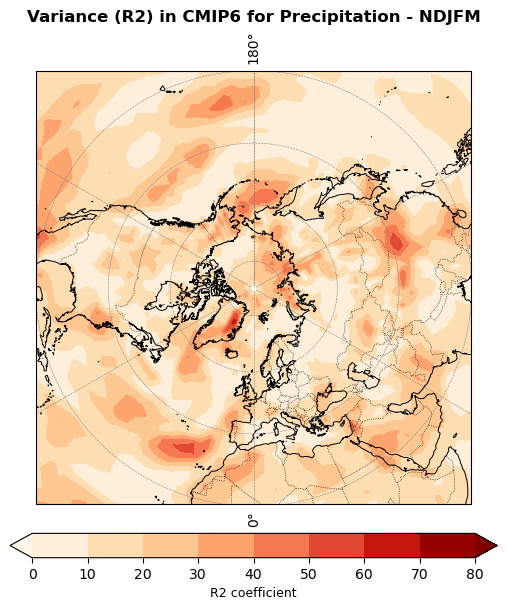

In [1]:
from storypy.evaluate.plot import plot_map
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

main_config = dict(
        work_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work',
    )

# Or directly read the data from the output file in the work_dir.
data_path = os.path.join(main_config['work_dir'], "regression_output/pr/R2.nc")
data = xr.open_dataset(data_path).pr * 100

levels = np.arange(0, 90, 10)
extent=[-180, 180, 20, 90]
fig = plot_map(data, levels, extent=extent,
          cmap="OrRd", title="Variance (R2) in CMIP6 for Precipitation - NDJFM",
          colorbar_label="R2 coefficient")

plt.show()

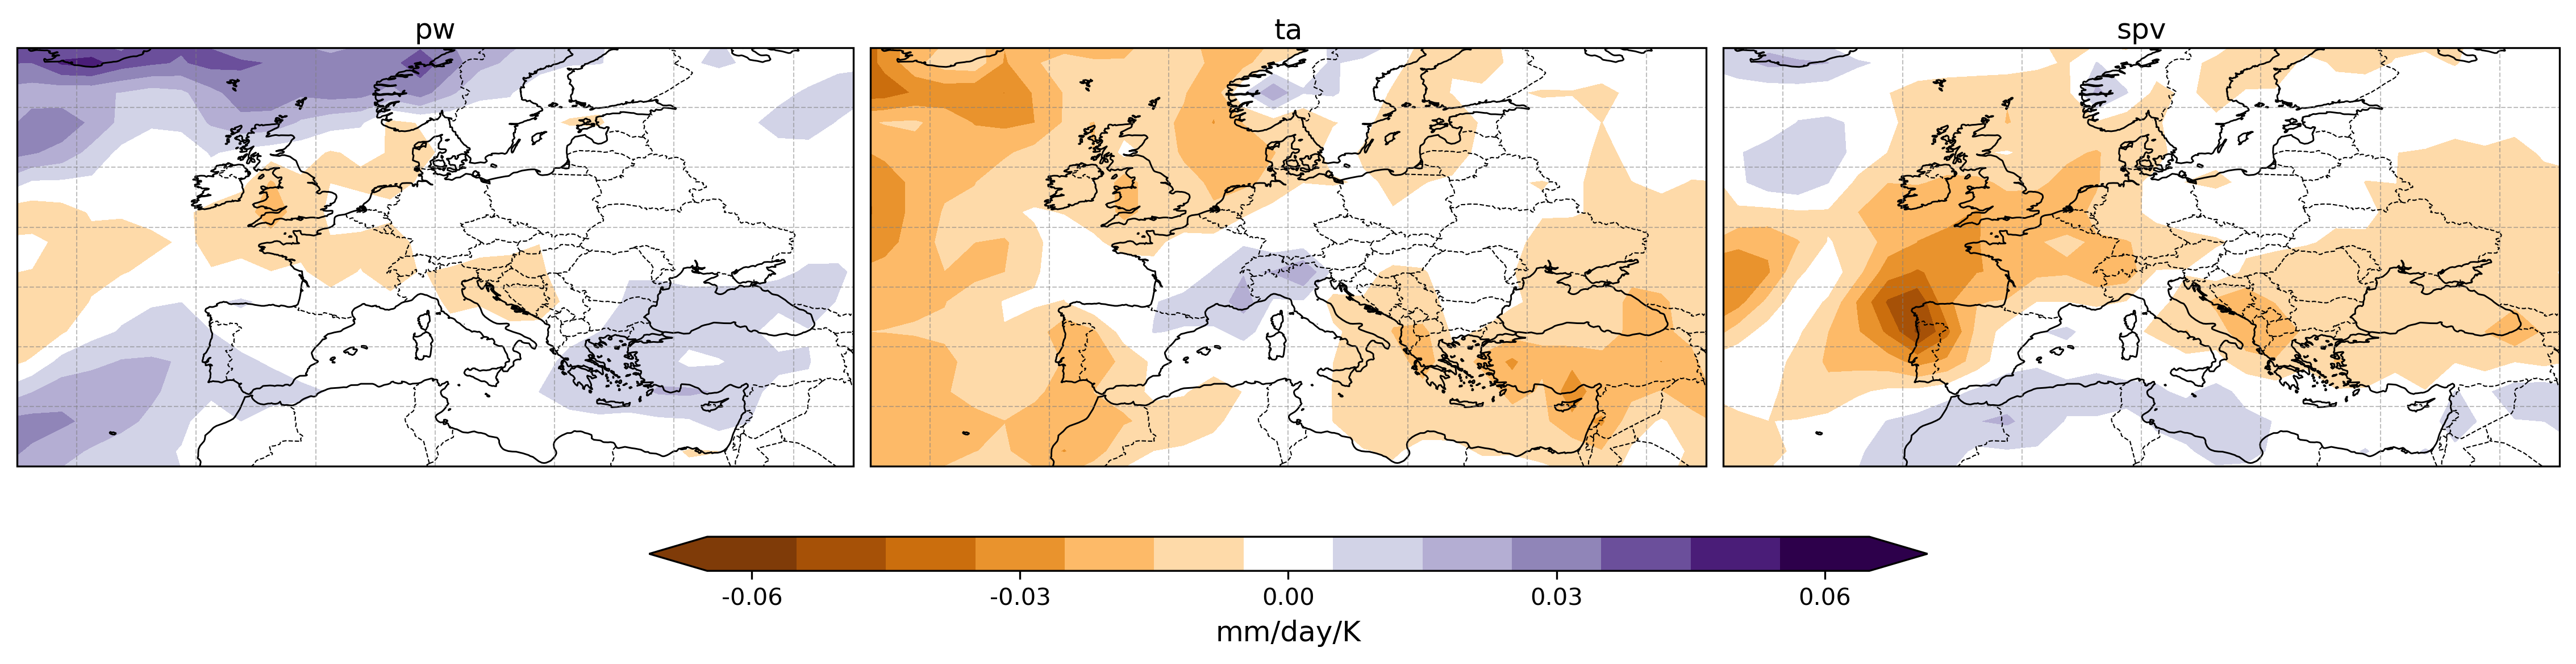

In [2]:
from storypy.evaluate.plot import regression_coefficient, create_multi_panel_figure
import numpy as np

main_config = dict(
        work_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work',
        plot_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/plots',
        box=([-25, 45, 30, 65]),
    )

target = "pr"
drivers = ["pw", "ta", "spv"]

coefficients, titles = regression_coefficient(main_config, target, drivers)
# coefficients = [c.sel(lat=slice(-88, 88)) for c in coefficients]

extent = [main_config["box"]] * 3
cmaps = ["PuOr"] * 3

create_multi_panel_figure(
    coefficients,
    extent,
    cmaps,
    titles,
    colorbar_label="mm/day/K",
    shared_colorbar=True,
    fixed_range=0.06,
    tick_levels=[-0.06, -0.03,
                  0.0, 0.03, 0.06],
)

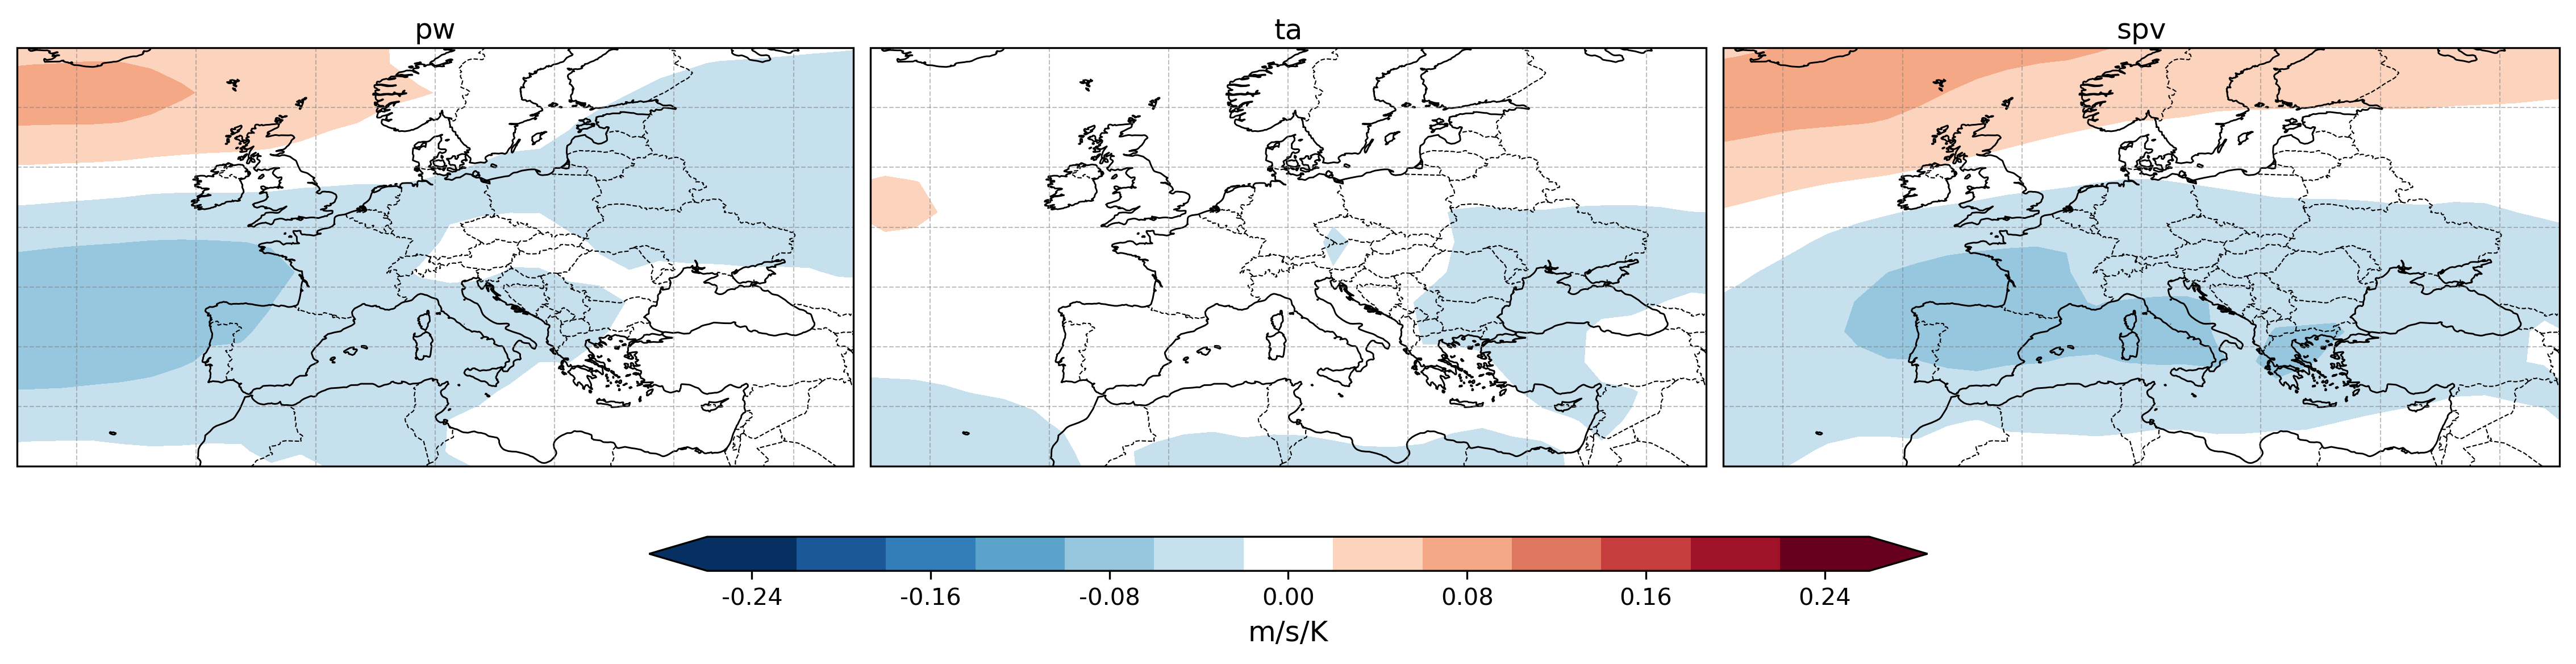

In [2]:
from storypy.evaluate.plot import regression_coefficient, create_multi_panel_figure
import numpy as np

main_config = dict(
        work_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work',
        plot_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/plots',
        box=([-25, 45, 30, 65]),
    )

target = "u850"
drivers = ["pw", "ta", "spv"]

coefficients, titles = regression_coefficient(main_config, target, drivers)
# coefficients = [c.sel(lat=slice(-88, 88)) for c in coefficients]

extent = [main_config["box"]] * 3
cmaps = ["RdBu_r"] * 3

create_multi_panel_figure(
    coefficients,
    extent,
    cmaps,
    titles,
    colorbar_label="m/s/K",
    shared_colorbar=True,
    fixed_range=0.24,
    tick_levels=[-0.24, -0.16, -0.08,
                  0.0, 0.08, 0.16, 0.24],
)

## Storyline Evaluation

Computes the four precipitation storyline corners plus the multi-model ensemble mean (MEM) using the regression coefficients. Three approaches are available depending on the scientific context:

| Approach | Method | Reference |
|----------|--------|-----------|
| **Default** | Single symmetric coefficient derived from bivariate chi-squared distribution assuming independent drivers (r=0) | Zappa & Shepherd (2017) |
| **Data-driven** | Asymmetric coefficients derived from the actual quantiles of the standardised driver distribution across models | Monerie et al. (2023) |
| **Correlated** | Two coefficients (i₁, i₂) accounting for the correlation between drivers - i₁ for same-direction storylines, i₂ for opposing storylines | Monerie et al. (2023) |

### Storyline corners

For two drivers `d0` and `d1`, the four corners are:

| Corner | Description |
|--------|-------------|
| high d1 / low d0 | Strong d1, weak d0 |
| high d1 / high d0 | Both drivers strong |
| low d1 / low d0 | Both drivers weak |
| low d1 / high d0 | Weak d1, strong d0 |

The precipitation change at each corner is evaluated as:

$$\frac{\Delta P}{\Delta T_0} = a_x \pm i \cdot b_x \pm i \cdot c_x$$

where $a_x$ is the MEM coefficient, $b_x$ and $c_x$ are the regression coefficients for each driver, $i$ is the storyline coefficient, and $\Delta T_0$ is the global warming level in K.

Using storyline coefficient: 1.2686


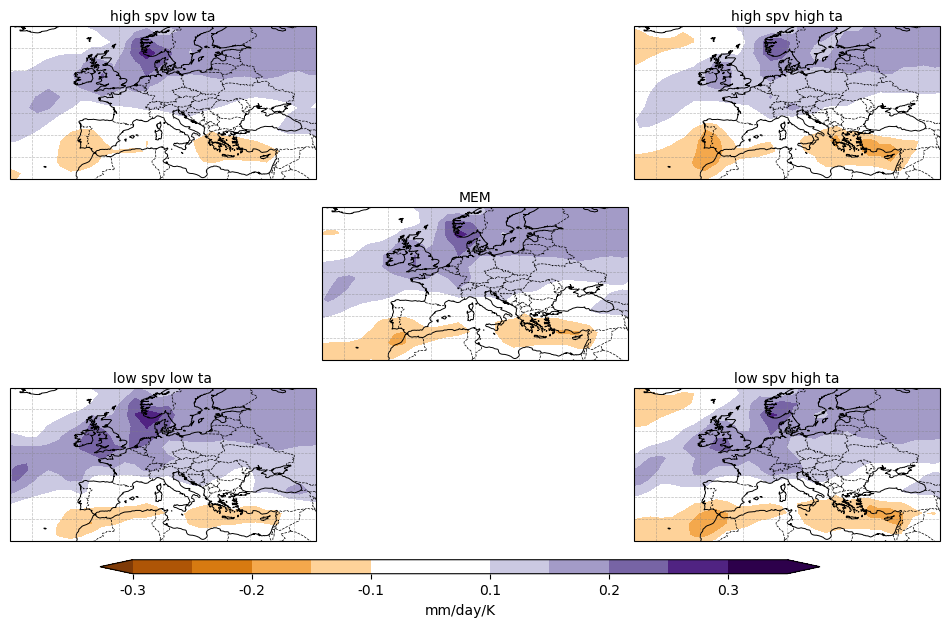

In [3]:
from storypy.evaluate.plot import plot_storyline_map, storyline_evaluation
import numpy as np

main_config = dict(
        work_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work',
        plot_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/plots',
        box=([-25, 45, 30, 65]),
    )

target = 'pr'
drivers = ['ta', 'spv']

# --- Call the function ---
storylines, titles = storyline_evaluation(
    main_config, target, drivers,
    confidence_level=0.8,   # default r=0, single coefficient ±1.26
)

# --- Plotting setup ---
cmaps = ['PuOr'] * 5
levels = [np.linspace(-0.3, 0.35, 12)] * 5 # np.arange(-0.3, 0.35, 0.05) --- IGNORE ---
extent = [main_config["box"]] * 5

fig = plot_storyline_map(
    storylines, extent, levels, cmaps, titles,
    colorbar_label="mm/day/K",
    white_pct=0.05
)

Using storyline coefficient: 1.2686


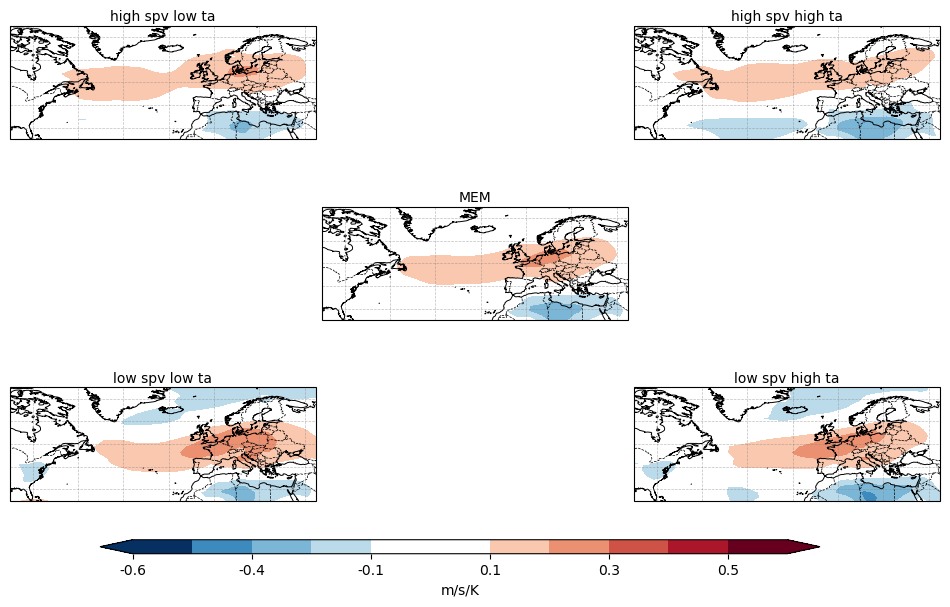

In [3]:
from storypy.evaluate.plot import plot_storyline_map, storyline_evaluation, bivariate_dist
import numpy as np

main_config = dict(
        work_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work',
        plot_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/plots',
        box=([-90, 45, 25, 75]),
    )

target = 'u850'
drivers = ['ta', 'spv']

# --- Call the function ---
storylines, titles = storyline_evaluation(
    main_config, target, drivers,
    confidence_level=0.8,   # default r=0, single coefficient ±1.26
)

# --- Plotting setup ---
cmaps = ['RdBu_r'] * 5
levels = [np.linspace(-0.6, 0.65, 12)] * 5 # np.arange(-0.3, 0.35, 0.05) --- IGNORE ---
extent = [main_config["box"]] * 5

fig = plot_storyline_map(
    storylines, extent, levels, cmaps, titles,
    colorbar_label="m/s/K",
    white_pct=0.05
)

In [ ]:
from storypy.evaluate.plot import plot_ellipse
import pandas as pd
import os

main_config = dict(
        work_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/work',
        plot_dir='/climca/people/ralawode/esmvaltool_output/za_sh_2017_20260423_084917/plots',
        # box=([-90, 45, 25, 75]),
    )
driver_path = os.path.join(main_config['work_dir'], "storyline_analysis/multiple_regression/remote_drivers/scaled_standardized_drivers.csv")
rds = pd.read_csv(driver_path, index_col=0).dropna()

models = rds.index.tolist()
fig = plot_ellipse(models,rds["ta"].values,rds["spv"].values,corr="no",x_label="Tropical warming",y_label="Stratospheric polar vortex",)